# 🚨 Customer Churn Prediction (XGBoost + SHAP)

Predicting churn is one of the most valuable tasks in retail 💰. Identify at-risk customers early → intervene with targeted marketing → save revenue.

**In this notebook, we will:**
1. ⏳ Define churn using a time-based split (Observation vs Prediction windows)
2. Engineer behavioral features for each customer (RFM + Tenure + Basket)
3. 🤖 Train an **XGBoost** model to predict churn probability
4. 🔍 Use **SHAP** to explain predictions — globally and per customer

In [1]:
# Loading libraries
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import joblib
import pathlib
import mlflow
import mlflow.xgboost

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler

import shap
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

try:
    from IPython.display import display
except ImportError:
    def display(obj): print(obj)

c:\Users\SAFAE ERAJI\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Loading & Churn Labeling
We need to define a cutoff point. We'll use the last 90 days as our "Churn Window".

In [2]:
# Loading pre-processed transaction data
processed_dir = pathlib.Path.cwd().parent / 'data' / 'processed'
df = pd.read_csv(processed_dir / 'online_retail_initial.csv', parse_dates=['InvoiceDate'])

In [3]:
# Defining churn: no purchase in the last 90 days
max_date = df['InvoiceDate'].max()
cutoff_date = max_date - pd.Timedelta(days=90)

In [4]:
print(f"📅 Dataset Max Date: {max_date.date()}")
print(f"📅 Cutoff Date (90 days before): {cutoff_date.date()}")

📅 Dataset Max Date: 2011-12-09
📅 Cutoff Date (90 days before): 2011-09-10


In [5]:
# Splitting into observation window (features) and prediction window (labels)
obs_df = df[df['InvoiceDate'] <= cutoff_date]
future_df = df[df['InvoiceDate'] > cutoff_date]

In [6]:
# Customers present in observation window
customers_obs = obs_df['CustomerID'].dropna().unique()

In [7]:
# Customers who returned in the prediction window
returning_customers = future_df['CustomerID'].dropna().unique()

In [8]:
# Label: Churn = 1 (didn't return), 0 (returned)
labels = pd.DataFrame({'CustomerID': customers_obs})
labels['Churn'] = labels['CustomerID'].apply(lambda x: 0 if x in returning_customers else 1)

In [9]:
print(f"\n👥 Total Customers: {len(labels):,}")
print(f"📊 Churn Rate: {labels['Churn'].mean()*100:.1f}%")


👥 Total Customers: 5,346
📊 Churn Rate: 56.6%


## 2. Feature Engineering
We calculate features based solely on the observation period (`obs_df`).

In [10]:
# RFM features for the observation period
snapshot_date = obs_df['InvoiceDate'].max() + pd.Timedelta(days=1)

features = obs_df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()

features.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Extra features: Tenure and Average Basket Value
tenure = obs_df.groupby('CustomerID').agg({'InvoiceDate': lambda x: (snapshot_date - x.min()).days}).reset_index()
tenure.columns = ['CustomerID', 'Tenure']

features = features.merge(tenure, on='CustomerID')
features['AvgBasketValue'] = features['Monetary'] / features['Frequency']

# Merge with labels
final_df = features.merge(labels, on='CustomerID')
final_df.set_index('CustomerID', inplace=True)

display(final_df.head())

,Recency,Frequency,Monetary,Tenure,AvgBasketValue,Churn
CustomerID,,,,,,
12346.0,235,17,-51.74,635,-3.043529,1
12347.0,39,6,3402.39,314,567.065000,0
12348.0,158,4,1709.40,348,427.350000,0
12349.0,317,4,2646.99,645,661.747500,0
12350.0,220,1,334.40,220,334.400000,1


## 3. XGBoost Model Training
We use XGBoost because it handles non-linear relationships and missing values exceptionally well.

In [11]:
# Train/Test Split
X = final_df.drop('Churn', axis=1)
y = final_df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Handle class imbalance
churn_ratio = (y == 0).sum() / (y == 1).sum()

# Train XGBoost
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=churn_ratio,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(X_train, y_train)
print(f"✅ XGBoost trained | Class balance ratio: {churn_ratio:.1f}:1")

✅ XGBoost trained | Class balance ratio: 0.8:1


## 4. Evaluation

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.69      0.70      0.69       465
           1       0.76      0.76      0.76       605

    accuracy                           0.73      1070
   macro avg       0.73      0.73      0.73      1070
weighted avg       0.73      0.73      0.73      1070

📊 ROC-AUC Score: 0.8160
✅ Strong: AUC of 0.82 — model separates churners well.


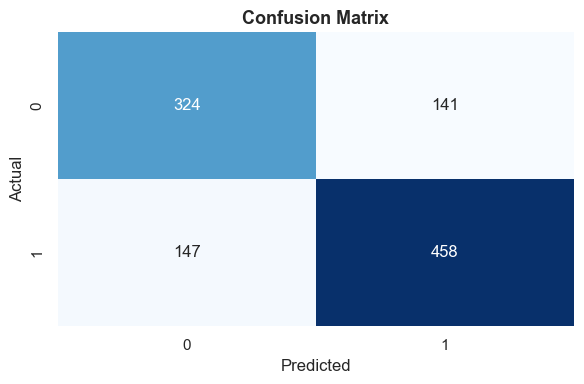

In [12]:
# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Evaluation
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

auc = roc_auc_score(y_test, y_prob)
print(f"📊 ROC-AUC Score: {auc:.4f}")

if auc > 0.80:
    print(f"✅ Strong: AUC of {auc:.2f} — model separates churners well.")
elif auc > 0.70:
    print(f"✅ Good: AUC of {auc:.2f} — useful for targeting.")
else:
    print(f"⚠️ Moderate: AUC of {auc:.2f} — consider additional features.")

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', 
            cmap='Blues', cbar=False)
plt.title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 5. SHAP Explainability
Feature importance tells us WHICH features matter. SHAP tells us HOW they push the prediction (higher or lower).

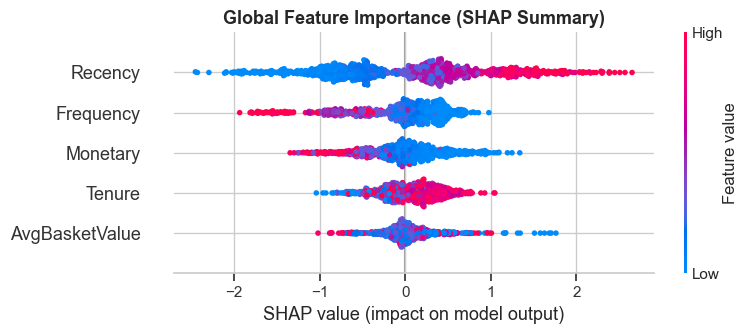

In [13]:
# SHAP Explainability
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Global feature importance
plt.title("Global Feature Importance (SHAP Summary)", fontsize=13, fontweight='bold')
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()

🔍 Explaining a single customer prediction:


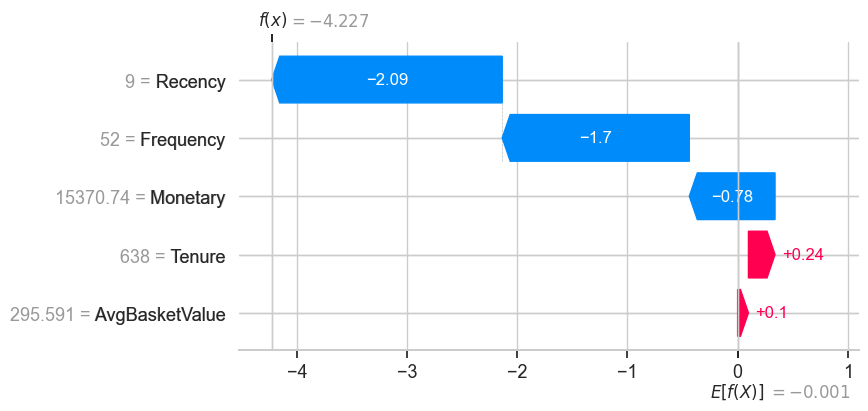

In [14]:
# Single customer explanation (waterfall plot — works everywhere)
print("🔍 Explaining a single customer prediction:")
shap.waterfall_plot(
    shap.Explanation(values=shap_values[0],
                     base_values=explainer.expected_value,
                     data=X_test.iloc[0].values,
                     feature_names=X_test.columns.tolist()),
    max_display=6
)

## 6. Persistence
Save the model and the SHAP explainer for the production dashboard.

In [15]:
# Save model, explainer, and metrics
os.makedirs('../models', exist_ok=True)

model.save_model('../models/churn_xgb_model.json')
joblib.dump(explainer, '../models/churn_shap_explainer.joblib')

metrics = {
    'AUC_ROC': round(float(auc), 4),
    'Churn_Rate': round(float(y.mean()), 4)
}
with open('../models/churn_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=4)

print("✅ Churn model, SHAP explainer, and metrics saved to '../models/'.")

✅ Churn model, SHAP explainer, and metrics saved to '../models/'.


## 7. Key Takeaways

- **90-day churn window** captures recent inactivity effectively — customers who vanish for 3 months are unlikely to return.
- **XGBoost handles class imbalance** via `scale_pos_weight` — no need to downsample.
- **SHAP reveals Recency is the #1 churn driver** — the longer a customer stays away, the higher the risk.
- **Model is production-ready**: Saved with SHAP explainer for real-time churn scoring and intervention.

## 8. MLFlow Tracking

In [16]:
mlflow.set_tracking_uri(f"file:{pathlib.Path.cwd().parent / 'mlruns'}")
mlflow.set_experiment("RetailPulse_Churn_Prediction")

with mlflow.start_run(run_name="XGBoost_Churn_Model"):
    mlflow.log_params({
        "n_estimators": 200,
        "max_depth": 4,
        "learning_rate": 0.1,
        "scale_pos_weight": round(float(churn_ratio), 2)
    })
    
    mlflow.log_metric("AUC_ROC", float(auc))
    mlflow.log_metric("Churn_Rate", float(y.mean()))
    
    mlflow.xgboost.log_model(model, artifact_path="churn_model")
    mlflow.log_artifact('../models/churn_shap_explainer.joblib')

print("✅ Churn model logged to MLflow!")

2026/04/27 01:02:37 INFO mlflow.tracking.fluent: Experiment with name 'RetailPulse_Churn_Prediction' does not exist. Creating a new experiment.


2026/04/27 01:02:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Churn model logged to MLflow!
